<a href="https://colab.research.google.com/github/samritha07/Deep-Learning/blob/main/DL_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TASK A: DATASET PREPARATION
# Roll No: 24BAD103

!pip install -q datasets

import numpy as np
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load Tiny Shakespeare dataset from Hugging Face
dataset = load_dataset("Trelis/tiny-shakespeare")

print("Dataset loaded successfully!")
print(dataset)

# 2. Explore the dataset and examine text samples
text = dataset["train"][0]["Text"]

print("\nFirst 1000 characters of the dataset:")
print(text[:1000])

print("\nTotal number of characters:", len(text))

# Display a few dataset samples
print("\nNumber of training samples:", len(dataset["train"]))
print("Number of test samples:", len(dataset["test"]))

print("\nFirst training sample:")
print(dataset["train"][0]["Text"][:500])

# 3. Convert text into lowercase
text = text.lower()

print("\nText after converting to lowercase:")
print(text[:500])

# Use the available text for processing
words = text.split()

print("\nTotal words:", len(words))

# 4. Tokenize the text into individual words
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

token_sequences = tokenizer.texts_to_sequences([text])[0]

print("\nTokenization completed.")

print("\nFirst 20 words:")
print(words[:20])

print("\nFirst 20 token values:")
print(token_sequences[:20])

# 5. Build vocabulary and assign unique integer index to each word
total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size:", total_words)

print("\nFirst 20 vocabulary words and their indexes:")
for word, index in list(tokenizer.word_index.items())[:20]:
    print(word, ":", index)

# 6. Generate input sequences for next-word prediction
sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(token_sequences)):
    sequence = token_sequences[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("\nNext-word prediction sequences generated.")
print("Number of sequences:", len(input_sequences))
print("Sequence shape:", input_sequences.shape)

# Separate input and target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("\nInput shape:", X.shape)
print("Target shape:", y.shape)

# 7. Apply sequence padding
X_padded = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("\nPadding completed.")
print("Padded input shape:", X_padded.shape)

# 8. Split into training and validation datasets
split_index = int(0.8 * len(X_padded))

X_train = X_padded[:split_index]
y_train = y[:split_index]

X_val = X_padded[split_index:]
y_val = y[split_index:]

print("\nDataset split completed.")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nValidation data:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# 9. Display one example
reverse_word_index = {
    index: word for word, index in tokenizer.word_index.items()
}

example_input = [
    reverse_word_index.get(index, "<UNK>")
    for index in X_train[0]
]

example_target = reverse_word_index.get(y_train[0], "<UNK>")

print("\nExample next-word prediction:")
print("Input words:", " ".join(example_input))
print("Target next word:", example_target)

print("\nTASK A COMPLETED SUCCESSFULLY!")

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

First 1000 characters of the dataset:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object

In [ ]:
# TASK B: IMPLEMENTING THE RNN MODEL
# Roll No: 24BAD103

import tensorflow as tf

# Create the RNN model
model = tf.keras.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(
        input_dim=total_words,
        output_dim=128,
        input_length=sequence_length
    ),

    # Simple RNN layer
    tf.keras.layers.SimpleRNN(128),

    # Dense output layer with Softmax activation
    tf.keras.layers.Dense(
        total_words,
        activation="softmax"
    )
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
print("\nRNN MODEL ARCHITECTURE")
print(model)

# Display model summary
print("\nMODEL SUMMARY")
model.summary()

print("\nTASK B COMPLETED SUCCESSFULLY!")


RNN MODEL ARCHITECTURE
<Sequential name=sequential, built=False>

MODEL SUMMARY


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


TASK B COMPLETED SUCCESSFULLY!


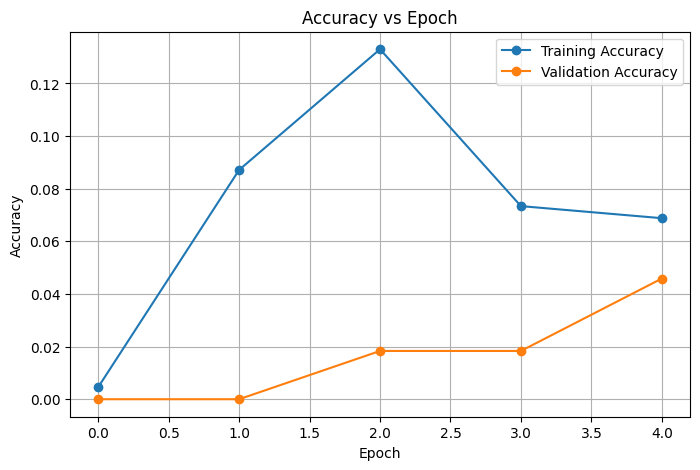

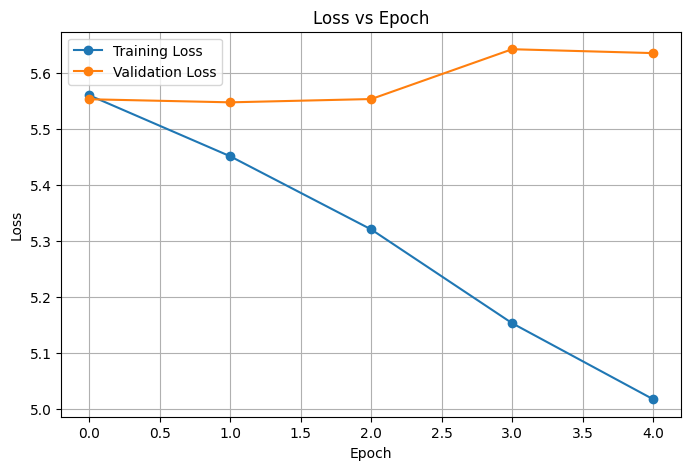

TASK C VISUALIZATION COMPLETED!


In [6]:
# TASK C: VISUALIZATION
# Roll No: 24BAD103

import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("TASK C VISUALIZATION COMPLETED!")

In [7]:
# TASK D: TEXT GENERATION USING RNN
# Roll No: 24BAD103

import numpy as np

# Function to generate text
def generate_text(seed_text, next_words=10):
    generated_text = seed_text.lower()

    for _ in range(next_words):
        # Convert seed text into token sequence
        token_list = tokenizer.texts_to_sequences([generated_text])[0]

        # Keep only the required sequence length
        token_list = token_list[-sequence_length:]

        # Apply padding
        token_list = np.array([
            [0] * (sequence_length - len(token_list)) + token_list
        ])

        # Predict the next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(
            predicted_probabilities[0]
        )

        # Convert predicted index to word
        predicted_word = reverse_word_index.get(
            predicted_word_index,
            ""
        )

        # Stop if no word is predicted
        if predicted_word == "":
            break

        # Add predicted word to generated text
        generated_text += " " + predicted_word

    return generated_text


# Seed 1
seed1 = "the king"
sample1 = generate_text(seed1, next_words=10)

print("SAMPLE 1")
print("Seed:", seed1)
print("Generated Text:", sample1)


# Seed 2
seed2 = "my lord"
sample2 = generate_text(seed2, next_words=10)

print("\nSAMPLE 2")
print("Seed:", seed2)
print("Generated Text:", sample2)


# Seed 3
seed3 = "good night"
sample3 = generate_text(seed3, next_words=10)

print("\nSAMPLE 3")
print("Seed:", seed3)
print("Generated Text:", sample3)


# Compare the generated samples
print("\nOBSERVATIONS")

print("1. Different seed inputs produce different generated text.")
print("2. The generated text shows some relationship to the seed words.")
print("3. The coherence and contextual relevance are limited because the Simple RNN was trained for only a small number of epochs.")
print("4. Increasing the training epochs and using a larger dataset can improve text generation quality.")

print("\nTASK D COMPLETED SUCCESSFULLY!")

SAMPLE 1
Seed: the king
Generated Text: the king the first the the first first first first first first

SAMPLE 2
Seed: my lord
Generated Text: my lord the the the the the first first first first first

SAMPLE 3
Seed: good night
Generated Text: good night the the first the the first first first first first

OBSERVATIONS
1. Different seed inputs produce different generated text.
2. The generated text shows some relationship to the seed words.
3. The coherence and contextual relevance are limited because the Simple RNN was trained for only a small number of epochs.
4. Increasing the training epochs and using a larger dataset can improve text generation quality.

TASK D COMPLETED SUCCESSFULLY!
